# Importing Libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Loading The Dataset

In [64]:
data = load_breast_cancer()
X = data.data
y = data.target

In [65]:
print(f"X shape :{X.shape}, y shape :{y.shape}")

X shape :(569, 30), y shape :(569,)


# Creating The model

In [66]:
# this function gives the expected values 0/1
def predict(X,w):
    probability = sigmoid(X, w)
    predictions = (probability >= 0.5).astype(int)
    return predictions


In [67]:
# this function returns the probability 0->1
def sigmoid(X, w):
    z = np.dot(X,w)
    return 1 / (1 + np.exp(-z))

In [68]:
# this function finds the cost 
def cost_function(w , X , y):
    m = X.shape[0]
    h = sigmoid(X, w)
    h = np.clip(h, 1e-15, 1 - 1e-15)
    cost = -(y * np.log(h) + (1 - y) * np.log(1 - h))
    return (1 / m) * np.sum(cost)

In [69]:
# this function finds the gradient(derivative)
def gradient(w, X, y):
    m = X.shape[0]
    h = sigmoid(X, w)
    errors = h - y
    dw = (1/m) * np.dot(X.T , errors)
    return dw

In [70]:
#this function returns a list that contains the cost for every iteration and the best w
def gradient_descent(X,y,learning_rate,iterations):
    w = np.zeros(X.shape[1])
    cost = []
    for i in range(iterations):
        cost.append(cost_function(w, X, y))
        w -= learning_rate * gradient(w, X, y)
    return cost,w

In [71]:
from sklearn.preprocessing import StandardScaler
m = X.shape[0]
scaler = StandardScaler()
X_features = X
X_features = scaler.fit_transform(X_features)
ones = np.ones((m,1))
X = np.concatenate((ones, X_features), axis=1)

# Result

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=42)
costs, w = gradient_descent(X_train , y_train , learning_rate=0.01 , iterations=5000)
predictions = predict(X_test, w)
accuracy = np.mean(predictions == y_test)
print(f"accuracy{accuracy}")
print(f"final cost :{costs[-1]}")

accuracy0.9824561403508771
final cost :0.07018283873872432


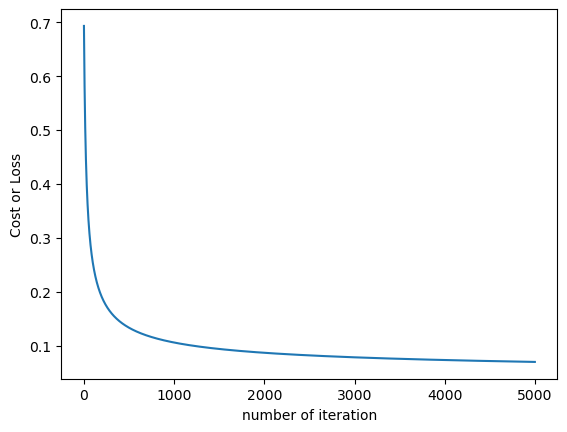

In [73]:
plt.plot(costs)
plt.xlabel("number of iteration")
plt.ylabel( "Cost or Loss")
plt.show()

# Sklearn VS Gradient descent

In [81]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
# we did this because we added a column of ones
model.fit(X_train[:,1:], y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [82]:
print(f"Sklearn weights : {model.coef_}")
print(f"My weights : {w}")
sk_predictions = model.predict(X_test[:, 1:])
sk_accuracy = np.mean(sk_predictions == y_test)

print(sk_accuracy)

Sklearn weights : [[-0.43464701 -0.39719369 -0.39606985 -0.46999027 -0.06739432  0.52671658
  -0.80767618 -1.1077114   0.24153785  0.07844689 -1.25057276  0.1889927
  -0.58988574 -0.91987672 -0.31656977  0.66906627  0.17107672 -0.31431731
   0.50499861  0.61176062 -0.87394431 -1.35751246 -0.58604724 -0.83803013
  -0.54737794  0.00589749 -0.95168648 -0.78040785 -1.19559714 -0.16293183]]
My weights : [ 0.45905481 -0.51639588 -0.60697337 -0.50138879 -0.53159129 -0.2003592
  0.01256412 -0.49552799 -0.62838324 -0.03022927  0.27325648 -0.65651467
  0.00587001 -0.48073208 -0.54207623 -0.10668949  0.38918826  0.1039344
 -0.08807908  0.21581462  0.40497456 -0.6941118  -0.83426545 -0.62456076
 -0.6610069  -0.56710001 -0.20036737 -0.54706317 -0.63235034 -0.62159481
 -0.12709959]
0.9736842105263158


In [83]:
print("My accuracy:", accuracy)
print("Sklearn:", sk_accuracy)

My accuracy: 0.9824561403508771
Sklearn: 0.9736842105263158
